In [ ]:
!gdown https://drive.google.com/uc?id=1UevWzkl1EIPppg19LP3UuNHyrSm1OPjv

Downloading...
From (original): https://drive.google.com/uc?id=1UevWzkl1EIPppg19LP3UuNHyrSm1OPjv
From (redirected): https://drive.google.com/uc?id=1UevWzkl1EIPppg19LP3UuNHyrSm1OPjv&confirm=t&uuid=e926a09c-d06f-45a7-81c3-7a5ecf9194e9
To: /content/sampah (2).zip
100% 531M/531M [00:06<00:00, 78.9MB/s]


In [ ]:
!unzip "/content/sampah (2).zip"

Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: sampah/Klasifikasi Sampah/anorganik/Karet/rubber_66.jpg  
  inflating: sampah/Klasifikasi Sampah/anorganik/Karet/rubber_67.jpg  
  inflating: sampah/Klasifikasi Sampah/anorganik/Karet/rubber_69.jpg  
  inflating: sampah/Klasifikasi Sampah/anorganik/Karet/rubber_7.jpg  
  inflating: sampah/Klasifikasi Sampah/anorganik/Karet/rubber_71.jpg  
  inflating: sampah/Klasifikasi Sampah/anorganik/Karet/rubber_72.jpg  
  inflating: sampah/Klasifikasi Sampah/anorganik/Karet/rubber_74.jpg  
  inflating: sampah/Klasifikasi Sampah/anorganik/Karet/rubber_77.jpg  
  inflating: sampah/Klasifikasi Sampah/anorganik/Karet/rubber_78.jpg  
  inflating: sampah/Klasifikasi Sampah/anorganik/Karet/rubber_79.jpg  
  inflating: sampah/Klasifikasi Sampah/anorganik/Karet/rubber_8.jpg  
  inflating: sampah/Klasifikasi Sampah/anorganik/Karet/rubber_80.jpg  
  inflating: sampah/Klasifikasi Sampah/anorganik/Karet/rubber_81.jpg  
  inflating: sampah/

In [ ]:
!pip install split-folders
import splitfolders
import os
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [ ]:
DATA_DIR = "Klasifikasi Sampah"

In [ ]:
import os
import shutil

DATA_DIR = 'sampah/Klasifikasi Sampah'          # folder asli (anorganik/, organik/, b3/)
NEW_DATA_DIR = 'Klasifikasi Sampah_flat' # folder baru, siap dipakai flow_from_directory

os.makedirs(NEW_DATA_DIR, exist_ok=True)

# Kategori besar = folder level 1 (anorganik, organik, b3)
categories = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
print(f"Kategori: {categories}")

for cat in categories:
    cat_path = os.path.join(DATA_DIR, cat)
    new_cat_path = os.path.join(NEW_DATA_DIR, cat)
    os.makedirs(new_cat_path, exist_ok=True)

    copied = 0
    # Jelajahi semua subfolder di dalam kategori (Kertas, Kaca, dst)
    for root, dirs, files in os.walk(cat_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                src = os.path.join(root, file)
                dst = os.path.join(new_cat_path, file)

                # Hindari nama file bentrok antar subfolder (misal ada 2 file "img1.jpg")
                if os.path.exists(dst):
                    name, ext = os.path.splitext(file)
                    subfolder_name = os.path.basename(root).replace(' ', '_')
                    dst = os.path.join(new_cat_path, f"{name}_{subfolder_name}{ext}")

                shutil.copy2(src, dst)
                copied += 1

    print(f"{cat}: {copied} gambar disalin ke {new_cat_path}")

Kategori: ['b3', 'anorganik', 'organik']
b3: 1962 gambar disalin ke Klasifikasi Sampah_flat/b3
anorganik: 4730 gambar disalin ke Klasifikasi Sampah_flat/anorganik
organik: 476 gambar disalin ke Klasifikasi Sampah_flat/organik


Jumlah kelas: 3
Nama kelas: ['anorganik', 'b3', 'organik']

anorganik: 4730 gambar
b3: 1962 gambar
organik: 476 gambar

Total gambar: 7168


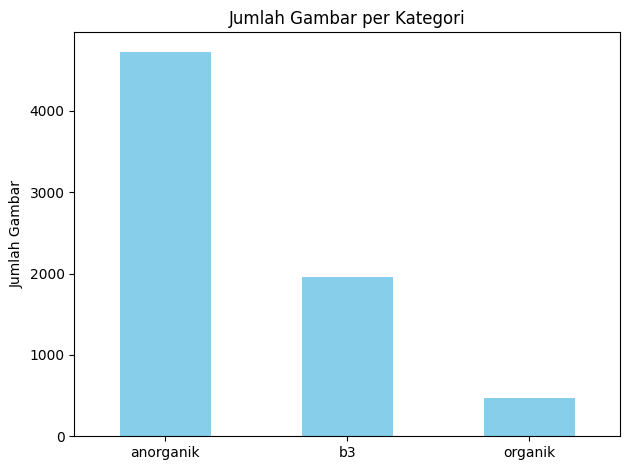


Rasio imbalance: 9.94x


In [ ]:
NEW_DATA_DIR = 'Klasifikasi Sampah_flat'

classes = sorted(os.listdir(NEW_DATA_DIR))
print(f"Jumlah kelas: {len(classes)}")
print(f"Nama kelas: {classes}\n")

counts = {}
for cls in classes:
    cls_path = os.path.join(NEW_DATA_DIR, cls)
    num_images = len(os.listdir(cls_path))
    counts[cls] = num_images
    print(f"{cls}: {num_images} gambar")

total = sum(counts.values())
print(f"\nTotal gambar: {total}")

# Cek balance
import pandas as pd
import matplotlib.pyplot as plt

df = pd.Series(counts)
df.plot(kind='bar', title='Jumlah Gambar per Kategori', color='skyblue')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

max_count = df.max()
min_count = df.min()
print(f"\nRasio imbalance: {max_count/min_count:.2f}x")

In [ ]:
DATA_DIR = 'Klasifikasi Sampah_flat'
OUTPUT_DIR = 'Klasifikasi Sampah_split'

splitfolders.ratio(
    DATA_DIR,
    output=OUTPUT_DIR,
    seed=42,
    ratio=(0.7, 0.15, 0.15)   # 70% train, 15% val, 15% test
)

print("Split selesai!")

Copying files: 7168 files [00:06, 1083.80 files/s]

Split selesai!


In [ ]:
import os

for split in ['train', 'val', 'test']:
    split_path = os.path.join(OUTPUT_DIR, split)
    print(f"\n📁 {split}/")
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        num_images = len(os.listdir(cls_path))
        print(f"  {cls}: {num_images} gambar")


📁 train/
  anorganik: 3311 gambar
  b3: 1373 gambar
  organik: 333 gambar

📁 val/
  anorganik: 709 gambar
  b3: 294 gambar
  organik: 71 gambar

📁 test/
  anorganik: 710 gambar
  b3: 295 gambar
  organik: 72 gambar


In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    'Klasifikasi Sampah_split/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

Found 5017 images belonging to 3 classes.


In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255)

val_gen = val_datagen.flow_from_directory(
    'Klasifikasi Sampah_split/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1074 images belonging to 3 classes.


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    'Klasifikasi Sampah_split/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1077 images belonging to 3 classes.


In [ ]:
print(f"Mapping kelas: {train_gen.class_indices}")
print(f"Train: {train_gen.samples} gambar")
print(f"Val: {val_gen.samples} gambar")
print(f"Test: {test_gen.samples} gambar")

Mapping kelas: {'anorganik': 0, 'b3': 1, 'organik': 2}
Train: 5017 gambar
Val: 1074 gambar
Test: 1077 gambar


In [ ]:
IMG_SIZE = 128
NUM_CLASSES = train_gen.num_classes

model = models.Sequential([
    # Conv Layer 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),

    # Conv Layer 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Conv Layer 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,067 (16.36 MB)

 Trainable params: 4,288,067 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15
)

Epoch 1/15
  6/157 ━━━━━━━━━━━━━━━━━━━━ 3:12 1s/step - accuracy: 0.5003 - loss: 1.2443

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.6580 - loss: 0.7744 - val_accuracy: 0.6955 - val_loss: 0.6772
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.7184 - loss: 0.6248 - val_accuracy: 0.7235 - val_loss: 0.6151
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.7475 - loss: 0.5778 - val_accuracy: 0.7896 - val_loss: 0.5046
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.7690 - loss: 0.5321 - val_accuracy: 0.8054 - val_loss: 0.4709
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.7889 - loss: 0.4869 - val_accuracy: 0.7998 - val_loss: 0.4808
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.8092 - loss: 0.4475 - val_accuracy: 0.8101 - val_loss: 0.4826
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.8296 - loss: 0.3966 - val_accuracy: 0.8026 - val_loss: 0.5118
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.8493 - loss: 0.3653 - val_accuracy: 0.815

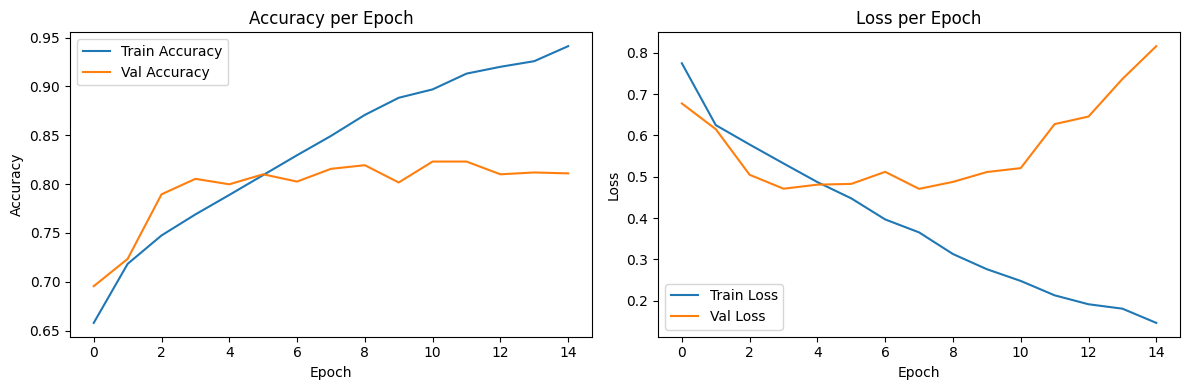

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Plot Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

   anorganik       0.80      0.93      0.86       710
          b3       0.77      0.46      0.57       295
     organik       0.69      0.71      0.70        72

    accuracy                           0.79      1077
   macro avg       0.75      0.70      0.71      1077
weighted avg       0.78      0.79      0.77      1077



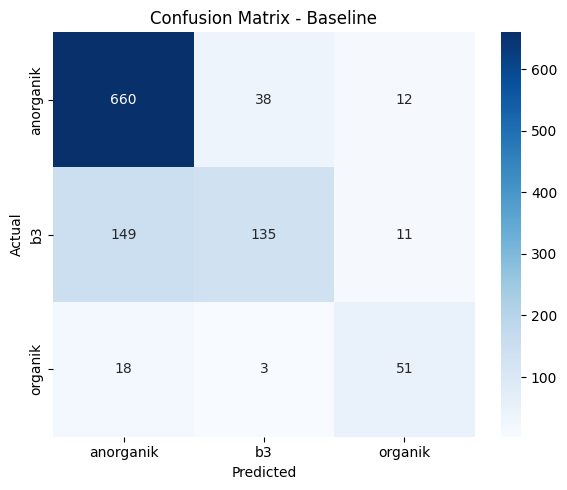

In [25]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Baseline')
plt.tight_layout()
plt.show()

Saving OIP (1).webp to OIP (1) (1).webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
Gambar: OIP (1) (1).webp
Prediksi: anorganik dengan keyakinan 1.00


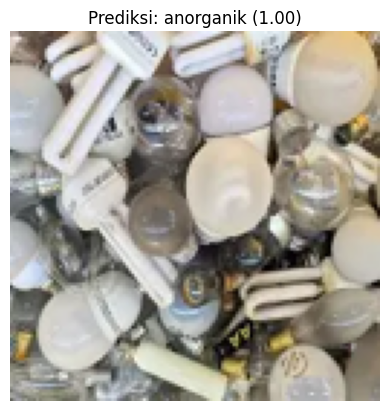

In [27]:
from google.colab import files
from tensorflow.keras.preprocessing import image


class_names = list(train_gen.class_indices.keys())

def predict_image(img_path, model, class_names, img_size=128):

    img = Image.open(img_path).convert('RGB')
    img = img.resize((img_size, img_size))


    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0


    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]
    confidence = predictions[0][predicted_class_index]

    print(f"Gambar: {os.path.basename(img_path)}")
    print(f"Prediksi: {predicted_class_name} dengan keyakinan {confidence:.2f}")

    plt.imshow(img)
    plt.title(f"Prediksi: {predicted_class_name} ({confidence:.2f})")
    plt.axis('off')
    plt.show()


uploaded = files.upload()
img_path = list(uploaded.keys())[0]

predict_image(img_path, model, class_names, img_size=IMG_SIZE)